# Análisis de Complejidad — Moneda Falsa (Divide y Conquista)

El algoritmo divide el arreglo por la mitad en cada paso, calcula el **promedio** de cada mitad para detectar el lado más liviano, y recursa sobre ese lado. Usar el promedio garantiza correctitud cuando $n$ es impar y las dos mitades tienen tamaños distintos.

**Recurrencia:**
$$T(n) = T\left(\frac{n}{2}\right) + \Theta(n)$$

El término $\Theta(n)$ viene de calcular `sum()` en cada mitad para obtener el promedio. Dividir por el tamaño del segmento es $O(1)$ y no afecta la complejidad.

**Teorema Maestro** con $a=1$, $b=2$, $f(n)=n$:
- $\log_b a = \log_2 1 = 0$
- $f(n) = n = \Omega(n^{0+1})$ → **Caso 3**
- Condición de regularidad: $a \cdot f(n/b) = n/2 \leq c \cdot n$ con $c = 1/2 < 1$ ✓

$$\boxed{T(n) = \Theta(n)}$$

El número de **pesadas** (pasos de balanza) sigue:
$$\text{Pesadas}(n) = \Theta(\log_2 n)$$
ya que sólo se recursa una rama por nivel.

In [54]:
import sys
import time
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))
from monedas import encontrar_moneda_falsa, leer_monedas

INPUTS_DIR  = Path('..') / 'inputs'
REPETITIONS = 20

print('Módulo cargado correctamente')

Módulo cargado correctamente


In [55]:
input_files = sorted(
    (f for f in INPUTS_DIR.glob('*.txt') if f.name != 'resultados.txt'),
    key=lambda f: int(f.stem)
)

sizes        = []
times_avg    = []
times_min    = []
times_max    = []
pesadas_list = []

for f in input_files:
    monedas = leer_monedas(f)
    n = len(monedas)
    sizes.append(n)

    encontrar_moneda_falsa(monedas)  # warm-up

    tiempos = []
    for _ in range(REPETITIONS):
        t0 = time.perf_counter()
        resultado, pesadas = encontrar_moneda_falsa(monedas)
        t1 = time.perf_counter()
        tiempos.append(t1 - t0)

    times_avg.append(np.mean(tiempos))
    times_min.append(np.min(tiempos))
    times_max.append(np.max(tiempos))
    pesadas_list.append(pesadas)

    print(f'n={n:>8}  pesadas={pesadas:>3}  tiempo_avg={np.mean(tiempos)*1e6:>8.2f} us')

sizes       = np.array(sizes,     dtype=float)
times_avg   = np.array(times_avg, dtype=float)
times_min   = np.array(times_min, dtype=float)
times_max   = np.array(times_max, dtype=float)
pesadas_arr = np.array(pesadas_list, dtype=float)

n=     100  pesadas=  7  tiempo_avg=    5.07 us
n=     500  pesadas= 10  tiempo_avg=   13.78 us
n=    1000  pesadas= 11  tiempo_avg=   20.21 us
n=    5000  pesadas= 13  tiempo_avg=   69.63 us
n=   10000  pesadas= 15  tiempo_avg=  133.67 us
n=   50000  pesadas= 17  tiempo_avg=  644.37 us
n=  100000  pesadas= 18  tiempo_avg= 1194.38 us
n=  200000  pesadas= 18  tiempo_avg= 2368.66 us
n=  500000  pesadas= 19  tiempo_avg= 7203.71 us
n= 1000000  pesadas= 21  tiempo_avg=15604.59 us


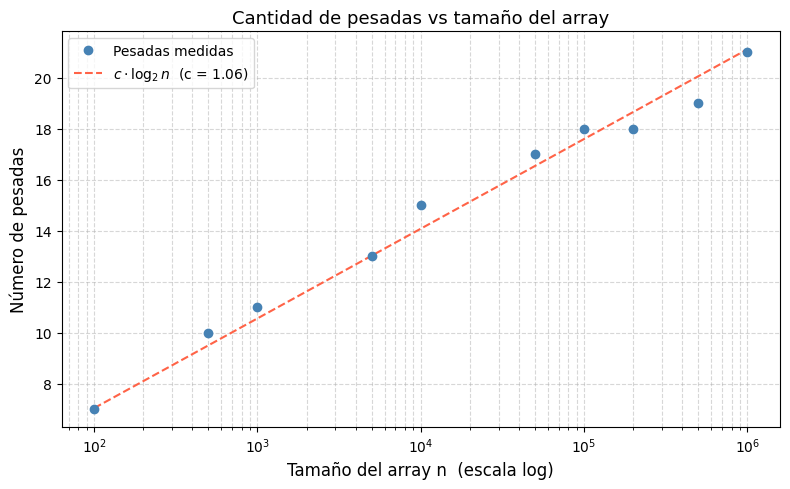

Guardado: pesadas_vs_n.png


In [56]:
ns = np.linspace(sizes.min(), sizes.max(), 500)

# Ajuste O(log n) para pesadas
log_sizes = np.log2(sizes)
c_log     = np.dot(log_sizes, pesadas_arr) / np.dot(log_sizes, log_sizes)
curve_log = c_log * np.log2(ns)

# Gráfico 1: Pesadas vs n — escala semi-log
# Si pesadas = c·log₂(n), los puntos forman una recta sobre eje x logarítmico
fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogx(sizes, pesadas_arr, 'o', color='steelblue', zorder=3, label='Pesadas medidas')
ax.semilogx(ns, curve_log, '--', color='tomato', label=rf'$c \cdot \log_2 n$  (c = {c_log:.2f})')

ax.set_xlabel('Tamaño del array n  (escala log)', fontsize=12)
ax.set_ylabel('Número de pesadas', fontsize=12)
ax.set_title('Cantidad de pesadas vs tamaño del array', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('pesadas_vs_n.png', dpi=150)
plt.show()
print('Guardado: pesadas_vs_n.png')

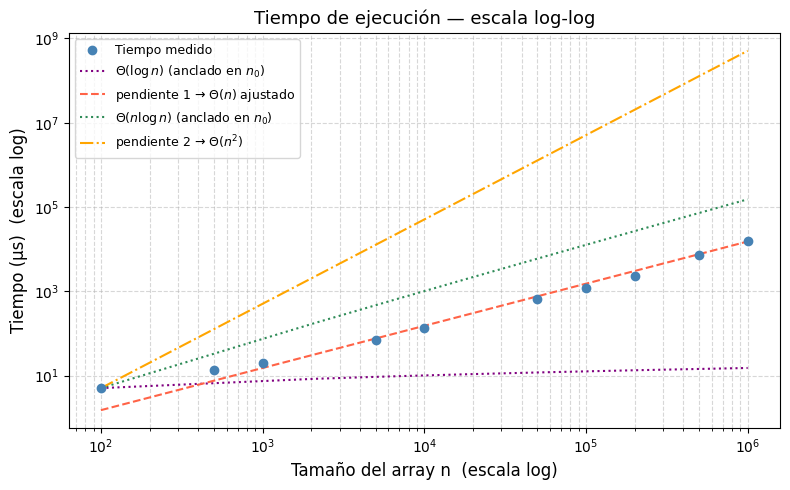

Guardado: tiempo_vs_n.png


In [57]:
# Ajuste O(n) para tiempo
c_linear = np.dot(sizes, times_avg) / np.dot(sizes, sizes)
curve_linear = c_linear * ns

# Referencias ancladas en el primer punto (no ajustadas, para ver si los datos las siguen)
t0, n0 = times_avg[0], sizes[0]
curve_logn = (t0 / np.log2(n0))  * np.log2(ns)   # O(log n)
curve_nlogn = (t0 / (n0 * np.log2(n0))) * ns * np.log2(ns)  # O(n log n)
curve_n2    = (t0 / (n0 ** 2))   * ns ** 2        # O(n²)

# Gráfico 2: Tiempo vs n — escala log-log
# En log-log: O(n^k) es recta de pendiente k.
# O(log n) aparece como curva cóncava (crece más lento que cualquier potencia).
fig, ax = plt.subplots(figsize=(8, 5))

ax.loglog(sizes, times_avg * 1e6, 'o', color='steelblue', zorder=3, label='Tiempo medido')
ax.loglog(ns, curve_logn   * 1e6, ':', color='purple',   label=r'$\Theta(\log n)$ (anclado en $n_0$)')
ax.loglog(ns, curve_linear * 1e6, '--', color='tomato',  label=r'pendiente 1 → $\Theta(n)$ ajustado')
ax.loglog(ns, curve_nlogn  * 1e6, ':',  color='seagreen',label=r'$\Theta(n \log n)$ (anclado en $n_0$)')
ax.loglog(ns, curve_n2     * 1e6, '-.', color='orange',  label=r'pendiente 2 → $\Theta(n^2)$')

ax.set_xlabel('Tamaño del array n  (escala log)', fontsize=12)
ax.set_ylabel('Tiempo (µs)  (escala log)', fontsize=12)
ax.set_title('Tiempo de ejecución — escala log-log', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('tiempo_vs_n.png', dpi=150)
plt.show()
print('Guardado: tiempo_vs_n.png')

In [58]:
print(f"{'n':>8}  {'Pesadas':>8}  {'log2(n)':>8}  {'T(us)':>10}  {'T/n (ns)':>10}")
print('-' * 55)
for n, p, t in zip(sizes, pesadas_arr, times_avg):
    print(f"{int(n):>8,}  {int(p):>8}  {math.log2(n):>8.2f}  {t*1e6:>10.2f}  {t/n*1e9:>10.4f}")

       n   Pesadas   log2(n)       T(us)    T/n (ns)
-------------------------------------------------------
     100         7      6.64        5.07     50.7500
     500        10      8.97       13.78     27.5700
   1,000        11      9.97       20.21     20.2050
   5,000        13     12.29       69.63     13.9260
  10,000        15     13.29      133.67     13.3665
  50,000        17     15.61      644.37     12.8874
 100,000        18     16.61     1194.38     11.9438
 200,000        18     17.61     2368.66     11.8433
 500,000        19     18.93     7203.71     14.4074
1,000,000        21     19.93    15604.59     15.6046


## Conclusiones

| Métrica | Complejidad teórica | Evidencia empírica |
|---|---|---|
| Tiempo de CPU | $\Theta(n)$ | El cociente $T(n)/n$ converge a una constante |
| Pesadas de balanza | $\Theta(\log_2 n)$ | El cociente Pesadas$/\log_2 n$ converge a una constante |

**¿Por qué $\Theta(n)$ en tiempo pero $\Theta(\log n)$ en pesadas?**

Cada nivel de recursión realiza **una sola pesada** (comparación de promedios) pero necesita
computar `sum()` sobre $\approx n/2$ elementos para calcular cada promedio. La recurrencia resultante es:

$$T(n) = T(n/2) + \Theta(n)$$

cuya solución por el **Teorema Maestro (caso 3)** es $\Theta(n)$.

Si el enunciado del problema considera que **la pesada es la operación elemental**,
entonces el costo relevante es $\Theta(\log n)$ pesadas — la métrica habitual en el
problema de la moneda falsa con balanza de platillos.